# Time Series Final Project - Master MVA

Authors : Romain Cargnello, Grégoire Josse

The goal of this project is to give a pytorch implementation of the article [Learning Representations for Time Series Clustering](https://github.com/qianlima-lab/DTCR/blob/master/Learning%20Representations%20for%20Time%20Series%20Clustering.pdf). We also run many experiments on the model to understand its behavior.

<span style="color:red">Important remark: This notebook just gives an idea of how the API of our model works. To find our experiments in detail, please refer to the file train.py, lines 440 to 472.
</span>


## Imports

In [1]:
import torch
import matplotlib.pyplot as plt
from ucr_loader import load_dataset, IndexedDataset, DataLoader
from dtcr_model import DTCR
from train import train_dtcr

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## Dataloading

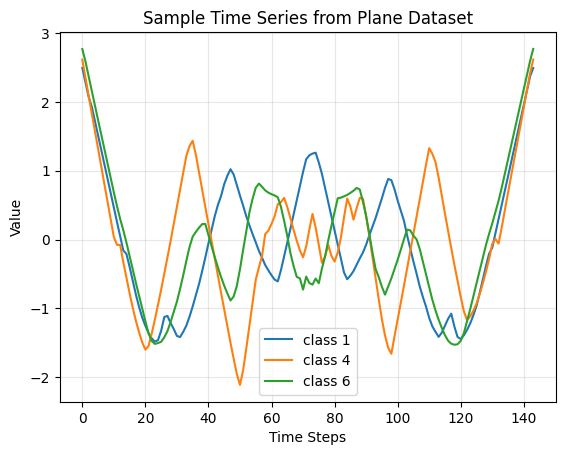

In [2]:
X_train, y_train, X_test, y_test = load_dataset(name="Plane")

plt.figure()
for i in range(3):
    plt.plot(X_train[i], label=f'class {y_train[i]}')
plt.title('Sample Time Series from Plane Dataset')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
train_ds = IndexedDataset(X_train, y_train)
test_ds  = IndexedDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

## Model initialization

In [4]:
seq_len = X_train.shape[1]
seq_dim = 1  # univariate time series

epochs=300 

# ---- Initialize Model ----
model = DTCR(
    input_size=seq_dim, # dimension of the sequence (univariate for UCR datasets)
    num_steps=seq_len, # length of the sequence
    cell_type="GRU", # (cf article)
    drnn_hidden_sizes=[50, 30, 30], # [100, 50, 50] or [50, 30, 30] (cf article)
    lamb=1e-3, # in [1, 1e-1, 1e-2, 1e-3] (cf article)
    class_num=7, # Plane dataset = 7 classes
    Kmeans_objective=True,
    classification_task=True
).to(DEVICE)

## Model training

Training DTCR:   0%|          | 0/300 [00:00<?, ?it/s]

Updating F...
Epoch 01: loss=1.7055 (recon=1.002697467803955, classif=0.6908877491950989, k-means=11.89410400390625), ACC=0.5905, ARI=0.4227
Epoch 05: loss=1.5023 (recon=0.8379872441291809, classif=0.6562202572822571, k-means=8.1090087890625), ACC=0.5333, ARI=0.3666
Epoch 10: loss=1.5168 (recon=0.8125680088996887, classif=0.6970309615135193, k-means=7.155517578125), ACC=0.5905, ARI=0.4849
Updating F...
Epoch 15: loss=1.5276 (recon=0.803338885307312, classif=0.7169622182846069, k-means=7.288818359375), ACC=0.5238, ARI=0.3555
Epoch 20: loss=1.5371 (recon=0.7886456847190857, classif=0.7365240454673767, k-means=11.979248046875), ACC=0.4667, ARI=0.3200
Updating F...
Epoch 25: loss=1.4238 (recon=0.7453705072402954, classif=0.6661490797996521, k-means=12.233642578125), ACC=0.6000, ARI=0.4110
Epoch 30: loss=1.6173 (recon=0.8461259007453918, classif=0.757767915725708, k-means=13.41015625), ACC=0.5048, ARI=0.3499
Updating F...
Epoch 35: loss=1.5146 (recon=0.7874326109886169, classif=0.7163093686

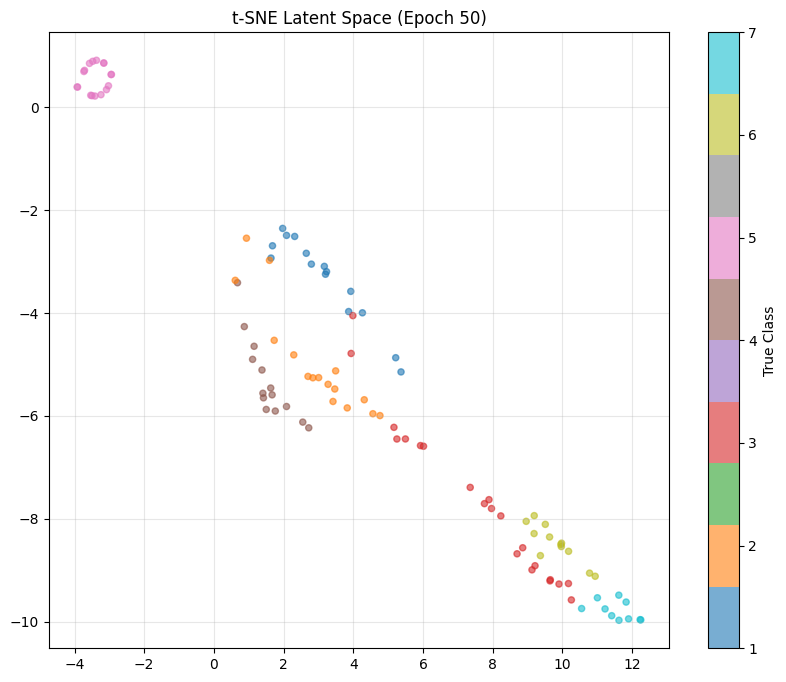

Updating F...
Epoch 55: loss=1.3974 (recon=0.7018082141876221, classif=0.6868630647659302, k-means=8.701904296875), ACC=0.5238, ARI=0.3843
Epoch 60: loss=1.1151 (recon=0.6915537118911743, classif=0.4141131639480591, k-means=9.3865966796875), ACC=0.5810, ARI=0.4392
Updating F...
Epoch 65: loss=1.4046 (recon=0.6846526861190796, classif=0.7093968987464905, k-means=10.5433349609375), ACC=0.6095, ARI=0.4660
Epoch 70: loss=0.9386 (recon=0.6818793416023254, classif=0.2457955926656723, k-means=10.8846435546875), ACC=0.6000, ARI=0.4323
Updating F...
Epoch 75: loss=1.5255 (recon=0.678063690662384, classif=0.8359604477882385, k-means=11.4393310546875), ACC=0.6571, ARI=0.5146
Epoch 80: loss=1.3551 (recon=0.6797671914100647, classif=0.6672066450119019, k-means=8.1461181640625), ACC=0.6476, ARI=0.4544
Updating F...
Epoch 85: loss=1.3500 (recon=0.6906728148460388, classif=0.6497095227241516, k-means=9.61956787109375), ACC=0.5524, ARI=0.4185
Epoch 90: loss=1.2500 (recon=0.6865392327308655, classif=0.5

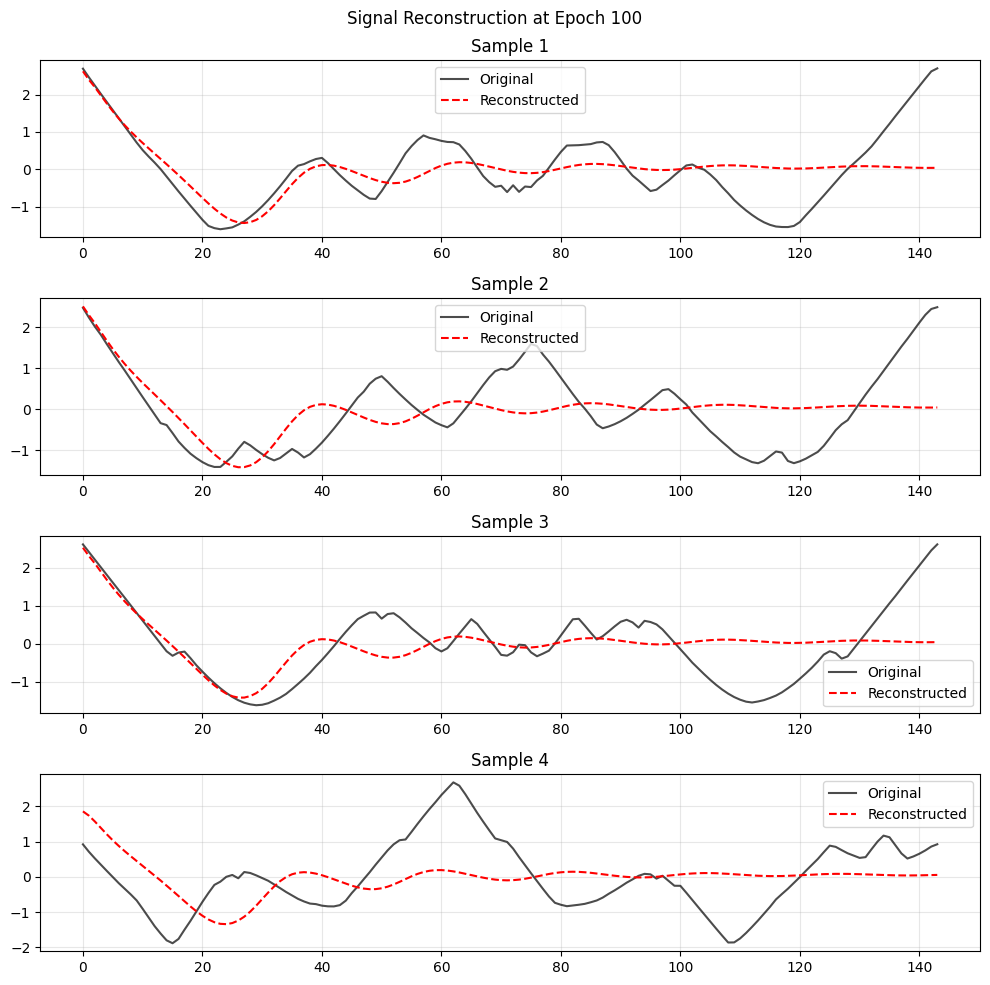

Updating F...
Epoch 105: loss=0.9824 (recon=0.6719270944595337, classif=0.30006861686706543, k-means=10.4080810546875), ACC=0.7048, ARI=0.6376
Epoch 110: loss=1.6701 (recon=0.668400228023529, classif=0.9869310259819031, k-means=14.80584716796875), ACC=0.6762, ARI=0.5249
Updating F...
Epoch 115: loss=1.6653 (recon=0.6708961725234985, classif=0.9773359298706055, k-means=17.10137939453125), ACC=0.6952, ARI=0.6611
Epoch 120: loss=0.9830 (recon=0.6744751334190369, classif=0.29284876585006714, k-means=15.64739990234375), ACC=0.7429, ARI=0.6142
Updating F...
Epoch 125: loss=1.2997 (recon=0.6695939302444458, classif=0.6142531633377075, k-means=15.8353271484375), ACC=0.6286, ARI=0.4971
Epoch 130: loss=0.8840 (recon=0.6764988303184509, classif=0.19239920377731323, k-means=15.06451416015625), ACC=0.4952, ARI=0.3993
Updating F...
Epoch 135: loss=0.8171 (recon=0.6849968433380127, classif=0.11432059854269028, k-means=17.74395751953125), ACC=0.8000, ARI=0.7088
Epoch 140: loss=1.2550 (recon=0.70161378

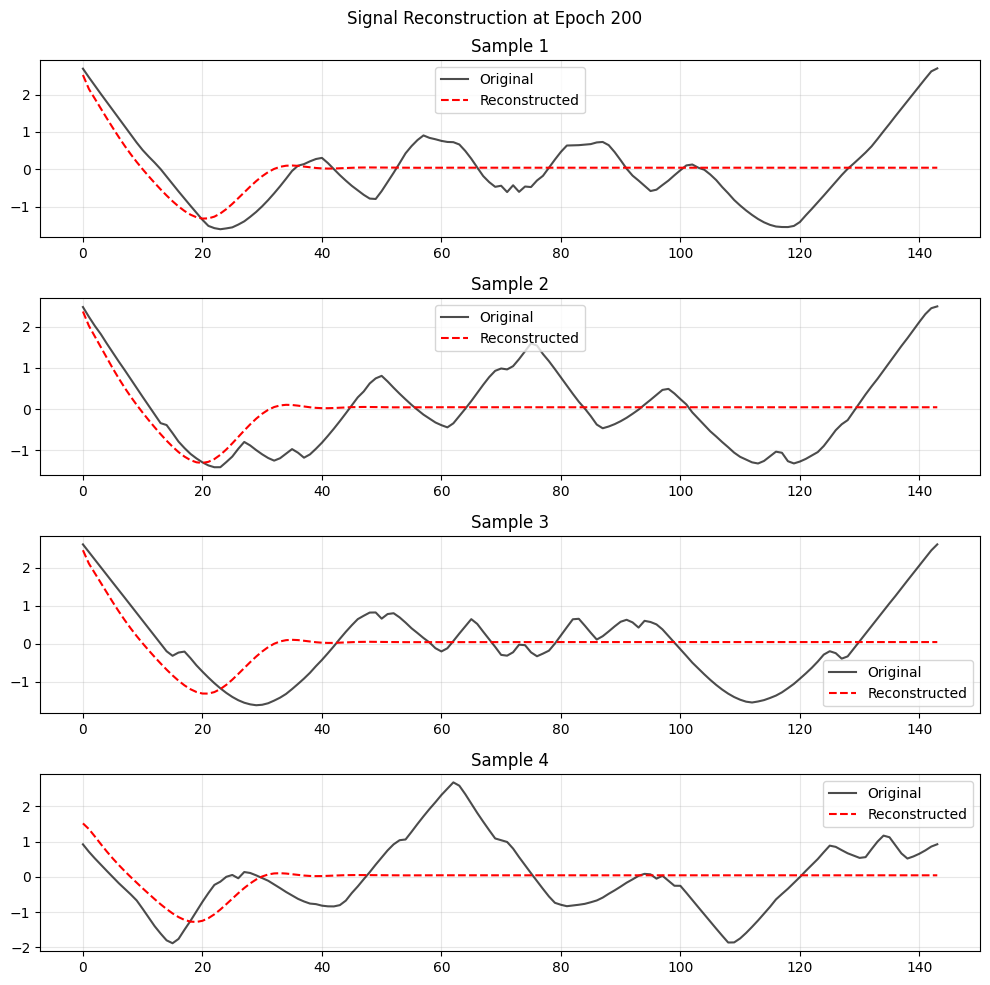

Updating F...
Epoch 205: loss=0.8036 (recon=0.7073810696601868, classif=0.07735500484704971, k-means=18.89599609375), ACC=0.7619, ARI=0.6661
Epoch 210: loss=0.7422 (recon=0.6902402639389038, classif=0.0356857068836689, k-means=16.3084716796875), ACC=0.8095, ARI=0.6856
Updating F...
Epoch 215: loss=0.7095 (recon=0.6779443621635437, classif=0.01540100947022438, k-means=16.1376953125), ACC=0.7238, ARI=0.5962
Epoch 220: loss=0.6948 (recon=0.6773377060890198, classif=0.0010014302097260952, k-means=16.4482421875), ACC=0.7048, ARI=0.5534
Updating F...
Epoch 225: loss=0.6996 (recon=0.679248034954071, classif=0.000328198162605986, k-means=19.994140625), ACC=0.7524, ARI=0.5957
Epoch 230: loss=0.6889 (recon=0.6650280356407166, classif=0.0014074923237785697, k-means=22.4945068359375), ACC=0.8095, ARI=0.7098
Updating F...
Epoch 235: loss=0.6853 (recon=0.661112904548645, classif=0.0005888581508770585, k-means=23.6068115234375), ACC=0.6762, ARI=0.5457
Epoch 240: loss=0.6797 (recon=0.6559122204780579,

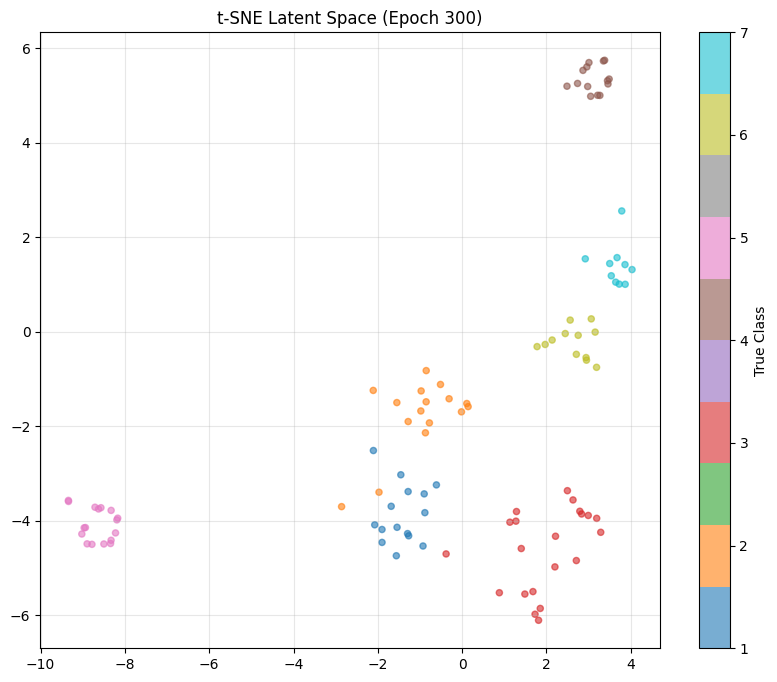

Visualizing signal vs reconstruction for Epoch 300...


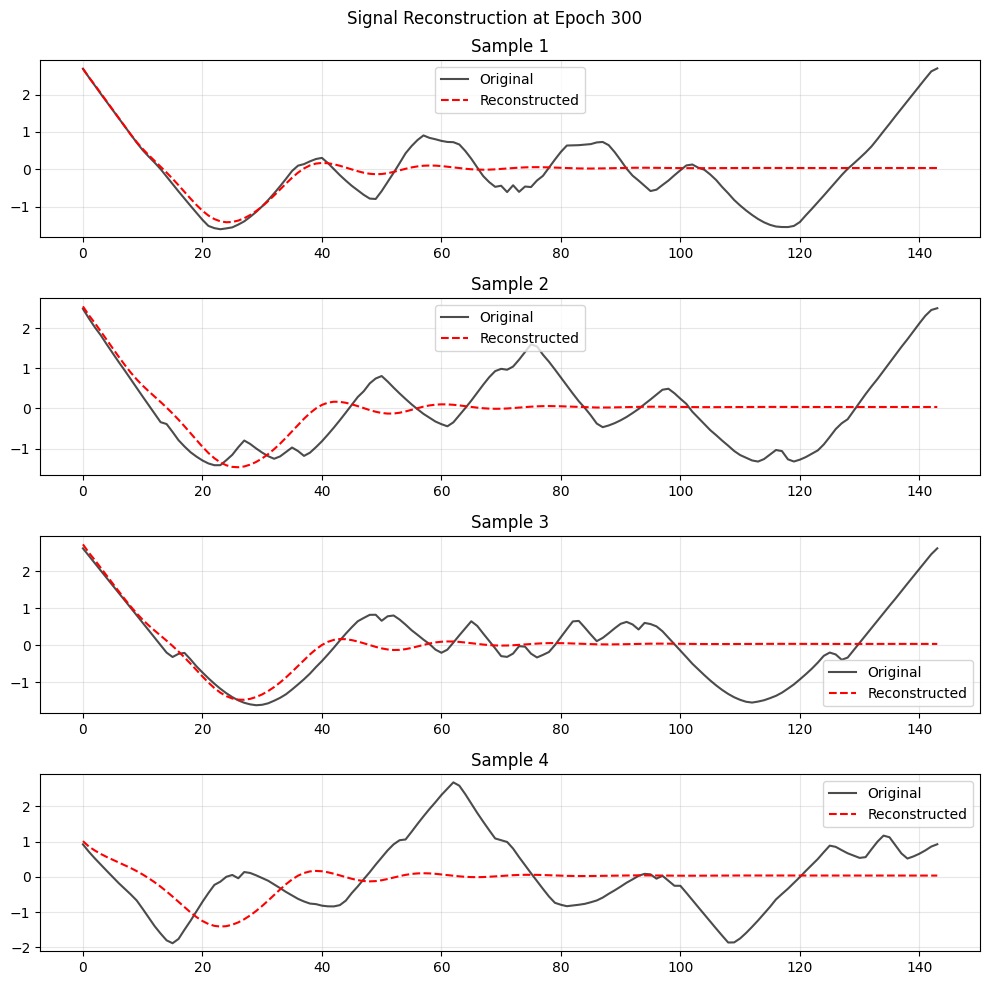

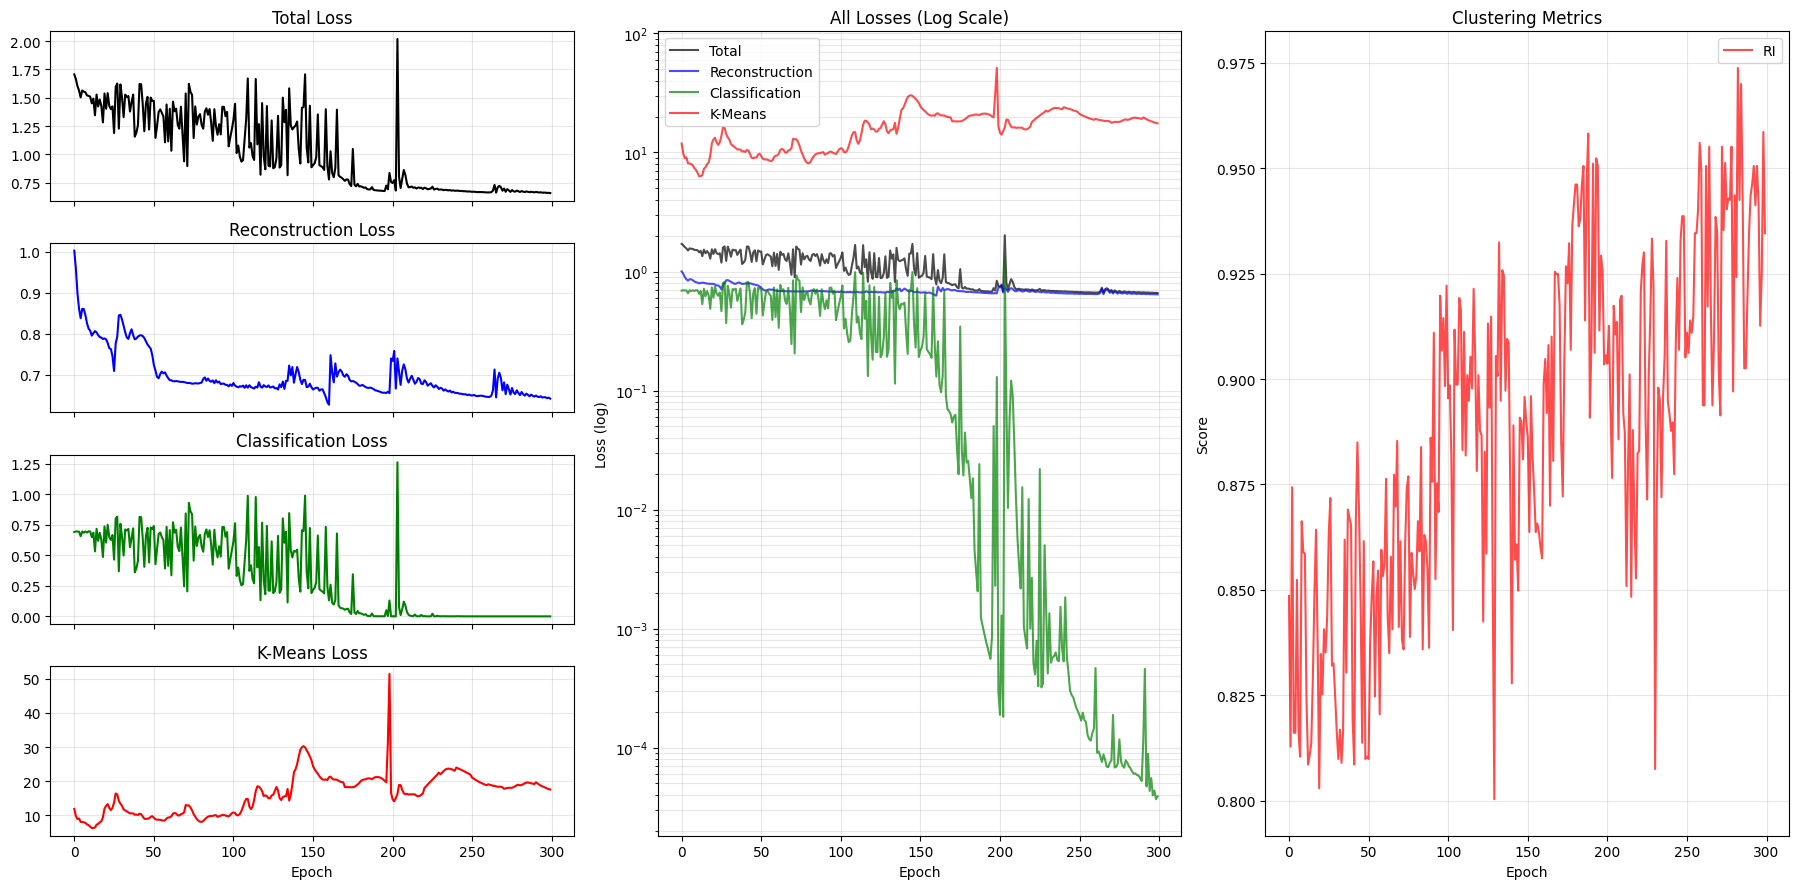

RI: 0.9738095238095238 NMI: 0.9288409513286044


In [5]:
max_RI, max_NMI = train_dtcr(train_loader, test_loader, model, epochs=epochs, lr=5e-3, verbose=True)
print(f"RI: {max_RI} NMI: {max_NMI}")